In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("All imports successful!")

All imports successful!


In [ ]:
# Column names — CMAPSS has no header row, so we define them manually
col_names = ['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3'] + \
            [f'sensor_{i}' for i in range(1, 22)]

# Load FD001 training set
train_df = pd.read_csv('../data/raw/train_FD001.txt', sep=r'\s+', header=None, names=col_names)

# Quick look
print(f"Shape: {train_df.shape}")
print(f"Engines in dataset: {train_df['unit_id'].nunique()}")
print(f"Columns: {list(train_df.columns)}")
train_df.head()

Shape: (20631, 26)
Engines in dataset: 100
Columns: ['unit_id', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/var/folders/bn/pm60wxsd46l_vxj_rw7xtpzm0000gn/T/ipykernel_61343/857866030.py:6: SyntaxWarning: invalid escape sequence '\s'
  train_df = pd.read_csv('../data/raw/train_FD001.txt', sep='\s+', header=None, names=col_names)


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
print("Missing values:", train_df.isnull().sum().sum())

# Basic statistics
train_df.describe().round(2)

Missing values: 0


,unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.00,20631.00,20631.00,20631.0,20631.0,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.0,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.00,20631.0,20631.0,20631.00,20631.00
mean,51.51,108.81,-0.00,0.0,100.0,518.67,642.68,1590.52,1408.93,14.62,21.61,553.37,2388.10,9065.24,1.3,47.54,521.41,2388.10,8143.75,8.44,0.03,393.21,2388.0,100.0,38.82,23.29
std,29.23,68.88,0.00,0.0,0.0,0.00,0.50,6.13,9.00,0.00,0.00,0.89,0.07,22.08,0.0,0.27,0.74,0.07,19.08,0.04,0.00,1.55,0.0,0.0,0.18,0.11
min,1.00,1.00,-0.01,-0.0,100.0,518.67,641.21,1571.04,1382.25,14.62,21.60,549.85,2387.90,9021.73,1.3,46.85,518.69,2387.88,8099.94,8.32,0.03,388.00,2388.0,100.0,38.14,22.89
25%,26.00,52.00,-0.00,-0.0,100.0,518.67,642.33,1586.26,1402.36,14.62,21.61,552.81,2388.05,9053.10,1.3,47.35,520.96,2388.04,8133.24,8.41,0.03,392.00,2388.0,100.0,38.70,23.22
50%,52.00,104.00,0.00,0.0,100.0,518.67,642.64,1590.10,1408.04,14.62,21.61,553.44,2388.09,9060.66,1.3,47.51,521.48,2388.09,8140.54,8.44,0.03,393.00,2388.0,100.0,38.83,23.30
75%,77.00,156.00,0.00,0.0,100.0,518.67,643.00,1594.38,1414.55,14.62,21.61,554.01,2388.14,9069.42,1.3,47.70,521.95,2388.14,8148.31,8.47,0.03,394.00,2388.0,100.0,38.95,23.37
max,100.00,362.00,0.01,0.0,100.0,518.67,644.53,1616.91,1441.49,14.62,21.61,556.06,2388.56,9244.59,1.3,48.53,523.38,2388.56,8293.72,8.58,0.03,400.00,2388.0,100.0,39.43,23.62


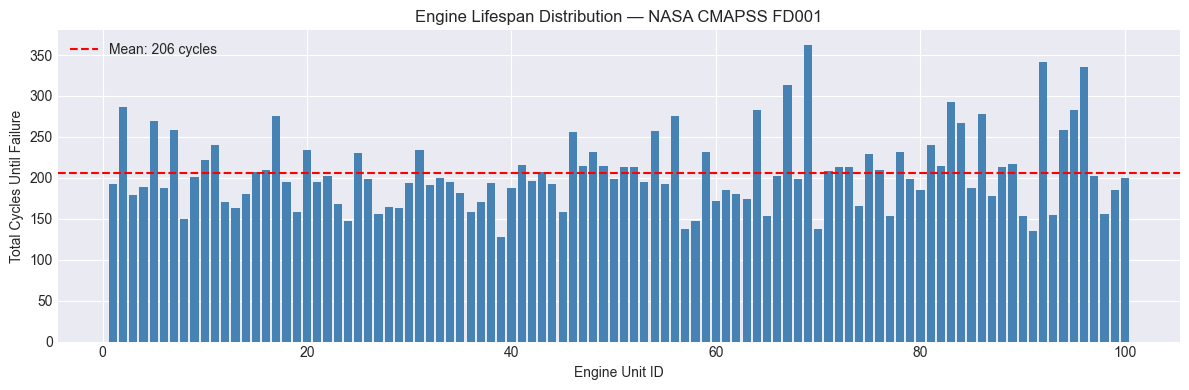

Shortest life: 128 cycles
Longest life:  362 cycles
Average life:  206 cycles


In [4]:
# Calculate max cycle (lifespan) per engine
engine_life = train_df.groupby('unit_id')['cycle'].max()

plt.figure(figsize=(12, 4))
plt.bar(engine_life.index, engine_life.values, color='steelblue', edgecolor='none')
plt.xlabel('Engine Unit ID')
plt.ylabel('Total Cycles Until Failure')
plt.title('Engine Lifespan Distribution — NASA CMAPSS FD001')
plt.axhline(engine_life.mean(), color='red', linestyle='--', label=f'Mean: {engine_life.mean():.0f} cycles')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Shortest life: {engine_life.min()} cycles")
print(f"Longest life:  {engine_life.max()} cycles")
print(f"Average life:  {engine_life.mean():.0f} cycles")

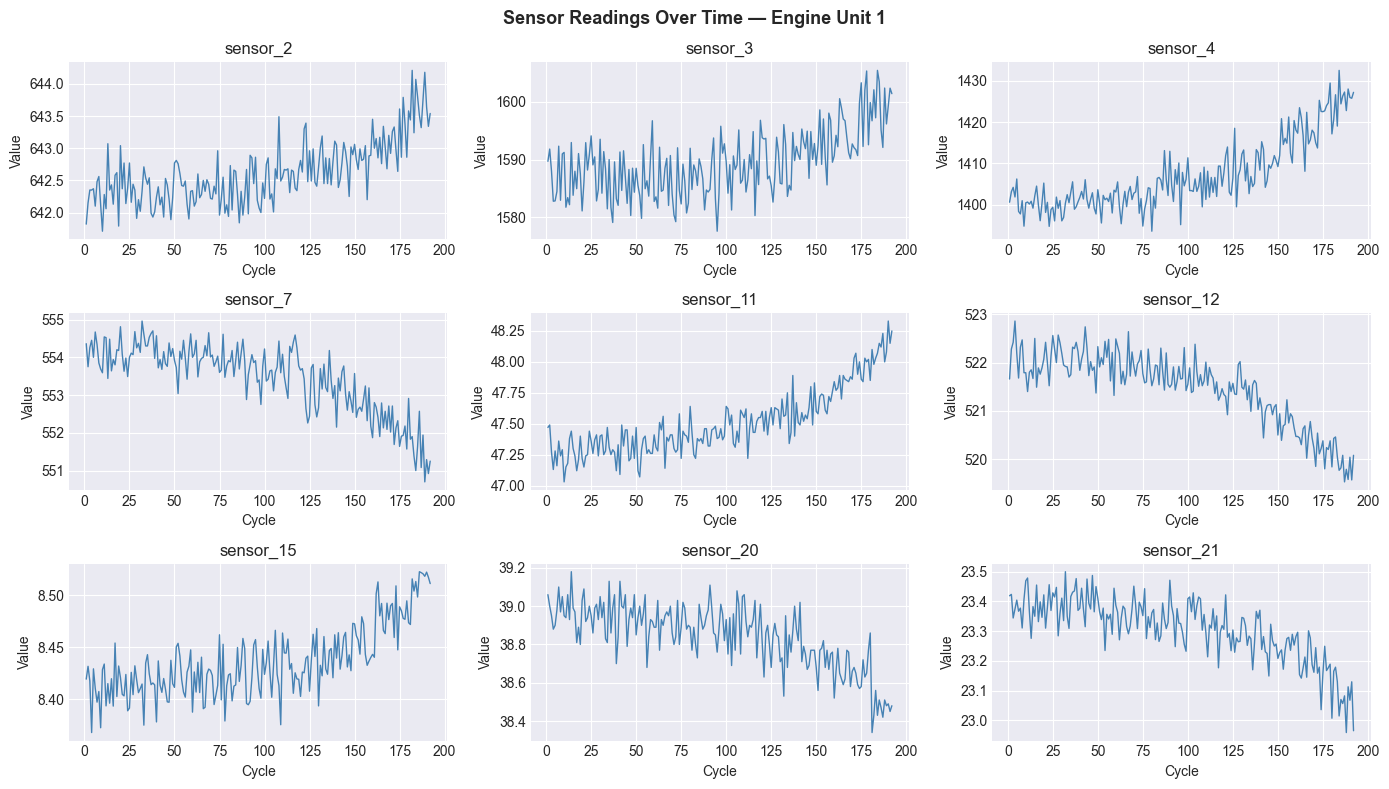

In [5]:
# Plot sensor readings over time for one engine
engine_id = 1
engine_data = train_df[train_df['unit_id'] == engine_id]

# Pick the most informative sensors (known from literature)
sensors_to_plot = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 
                   'sensor_11', 'sensor_12', 'sensor_15', 'sensor_20', 'sensor_21']

fig, axes = plt.subplots(3, 3, figsize=(14, 8))
axes = axes.flatten()

for i, sensor in enumerate(sensors_to_plot):
    axes[i].plot(engine_data['cycle'], engine_data[sensor], 
                 color='steelblue', linewidth=1)
    axes[i].set_title(sensor)
    axes[i].set_xlabel('Cycle')
    axes[i].set_ylabel('Value')

plt.suptitle(f'Sensor Readings Over Time — Engine Unit {engine_id}', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Why is the y-axis only labeled with "Value" and no discernible units? In the data files they are deliberately anonymized. We only know what some of the sensors are (insert graph).

Next we are looking for any sensors that are stagnant and don't have a visible nor meaningful change. We will drop them and not use their data for training since they probably don't assist with clueing us in to any degradations.

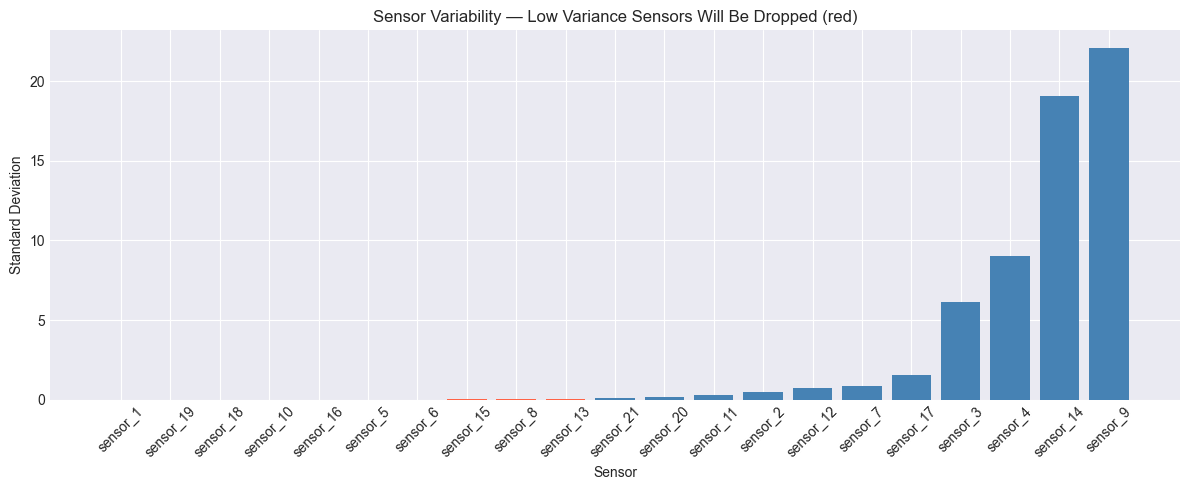

Low variance sensors to drop: ['sensor_1', 'sensor_19', 'sensor_18', 'sensor_10', 'sensor_16', 'sensor_5', 'sensor_6', 'sensor_15', 'sensor_8', 'sensor_13']


In [6]:
# Calculating standard deviation for each sensor across the entire dataset
sensor_cols = [f'sensor_{i}' for i in range(1, 22)]
sensor_std = train_df[sensor_cols].std().sort_values()

plt.figure(figsize=(12, 5))
colors = ['tomato' if v < 0.1 else 'steelblue' for v in sensor_std.values]
plt.bar(sensor_std.index, sensor_std.values, color=colors, edgecolor='none')
plt.xticks(rotation=45)
plt.xlabel('Sensor')
plt.ylabel('Standard Deviation')
plt.title('Sensor Variability — Low Variance Sensors Will Be Dropped (red)')
plt.tight_layout()
plt.show()

# Print the low variance sensors
low_variance = sensor_std[sensor_std < 0.1].index.tolist()
print(f"Low variance sensors to drop: {low_variance}")

In [7]:
# Define the sensors we'll use throughout the project
useful_sensors = [s for s in sensor_cols if s not in low_variance]
print(f"Keeping {len(useful_sensors)} sensors: {useful_sensors}")

# Also define our final feature columns (sensors + operational settings)
feature_cols = useful_sensors
print(f"\nFinal feature columns ({len(feature_cols)}):\n{feature_cols}")

Keeping 11 sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17', 'sensor_20', 'sensor_21']

Final feature columns (11):
['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_14', 'sensor_17', 'sensor_20', 'sensor_21']


Next we are calculating the remaining useful life of the engine.

In [8]:
# Calculate RUL for each row
# RUL = max cycle for that engine - current cycle
max_cycles = train_df.groupby('unit_id')['cycle'].max().reset_index()
max_cycles.columns = ['unit_id', 'max_cycle']

train_df = train_df.merge(max_cycles, on='unit_id')
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop(columns=['max_cycle'], inplace=True)

print(f"RUL range: {train_df['RUL'].min()} to {train_df['RUL'].max()}")
print(f"Sample — Engine 1, last 5 cycles:")
print(train_df[train_df['unit_id'] == 1][['unit_id', 'cycle', 'RUL']].tail())

RUL range: 0 to 361
Sample — Engine 1, last 5 cycles:
     unit_id  cycle  RUL
187        1    188    4
188        1    189    3
189        1    190    2
190        1    191    1
191        1    192    0


RUL = 0 means the engine just failed. RUL = 30 means it has 30 flights left. This column is what lets us later define "anomaly" — we'll label any engine window where RUL is below a threshold (e.g. 30 cycles) as entering a failure zone. That becomes our ground truth for evaluating how well the autoencoder detects anomalies.

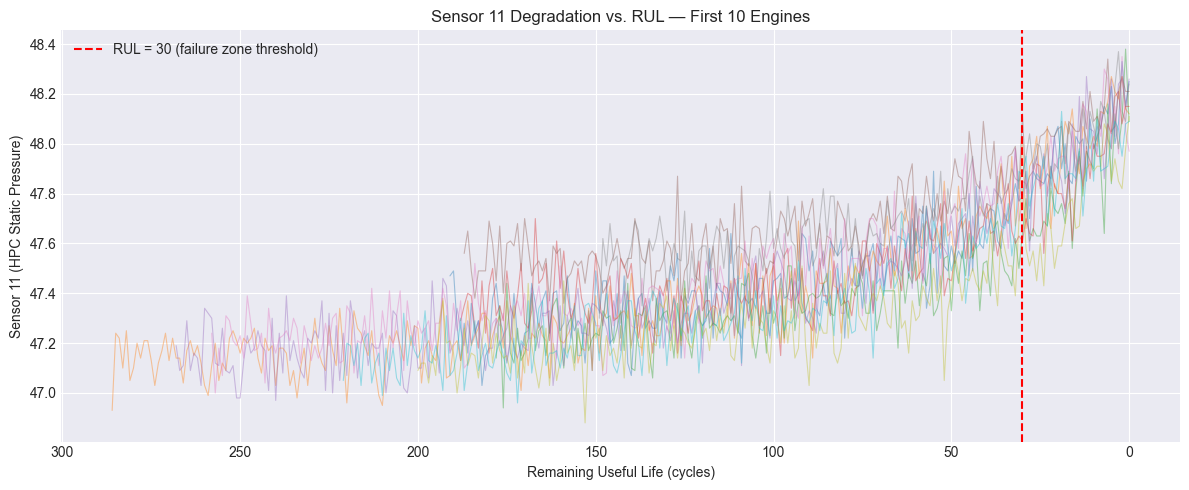

In [9]:
# Plot sensor_11 vs RUL for a few engines overlaid
plt.figure(figsize=(12, 5))

for engine_id in range(1, 11):  # first 10 engines
    eng = train_df[train_df['unit_id'] == engine_id]
    plt.plot(eng['RUL'], eng['sensor_11'], alpha=0.4, linewidth=0.8)

plt.axvline(x=30, color='red', linestyle='--', linewidth=1.5, label='RUL = 30 (failure zone threshold)')
plt.gca().invert_xaxis()  # RUL counts down, so flip x-axis
plt.xlabel('Remaining Useful Life (cycles)')
plt.ylabel('Sensor 11 (HPC Static Pressure)')
plt.title('Sensor 11 Degradation vs. RUL — First 10 Engines')
plt.legend()
plt.tight_layout()
plt.show()

As RUL approaches 0 (right side of the plot), sensor_11 should trend upward — confirming the sensor captures real degradation. The red dashed line at RUL=30 marks where we'll later define the failure zone that the model needs to detect.